In [719]:
import json
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [720]:
with open("20241107_management_insight_personalization_context.json", "r") as fp:
    personalization_context1 = json.load(fp)
    
with open("20241111_managementInsights4_personalization_context.json", "r") as fp:
    personalization_context2 = json.load(fp)

In [721]:
def is_valid_participant(analytics_event: dict) -> bool:
    return analytics_event["group"] == "Treatment"

personalization_context = {
    **{key: val for key, val in personalization_context1.items() if is_valid_participant(val)},
    **{key: val for key, val in personalization_context2.items() if is_valid_participant(val)},
}

helpfulness_evolution = {
    group: np.array([[int] for _, val in {**personalization_context1, **personalization_context2}.items()])
    for group in ["Treatment", "Control"]}

In [722]:
helpfulness_evolution = {
    group: np.array([[int(request["userInput"]) for request in val["requestStack"]] 
                     for key, val in personalization_context2.items() if val["group"] == group])
    for group in ["Treatment", "Control"]
}

(0.5, 7.5)

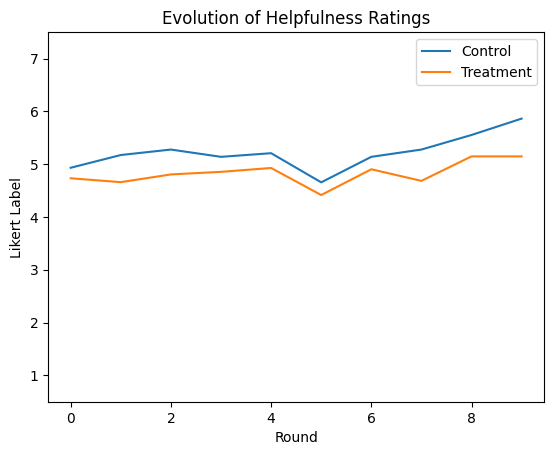

In [723]:
plt.plot(helpfulness_evolution["Control"].mean(axis=0))
plt.plot(helpfulness_evolution["Treatment"].mean(axis=0))
plt.legend(["Control", "Treatment"])
plt.title("Evolution of Helpfulness Ratings")
plt.xlabel("Round")
plt.ylabel("Likert Label")
plt.ylim(0.5,7.5)

In [724]:
reward_by_hyperparameter_level = np.array([
    [int(request["reward"]) * np.array(response["encoding"])
     for request, response in zip(personalization_context["requestStack"], personalization_context["responseStack"][1:])
    ] for _, personalization_context in personalization_context.items()])

d

In [725]:
encoding_evolution[:,0,:].shape

(78, 15)

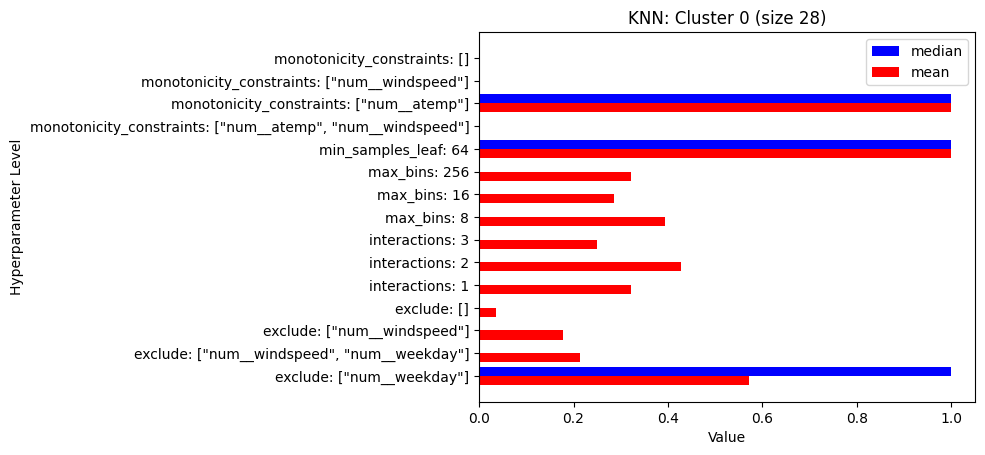

In [727]:
plot_cluster(data, labels, 0, hyperparameterLevelList, "KNN")

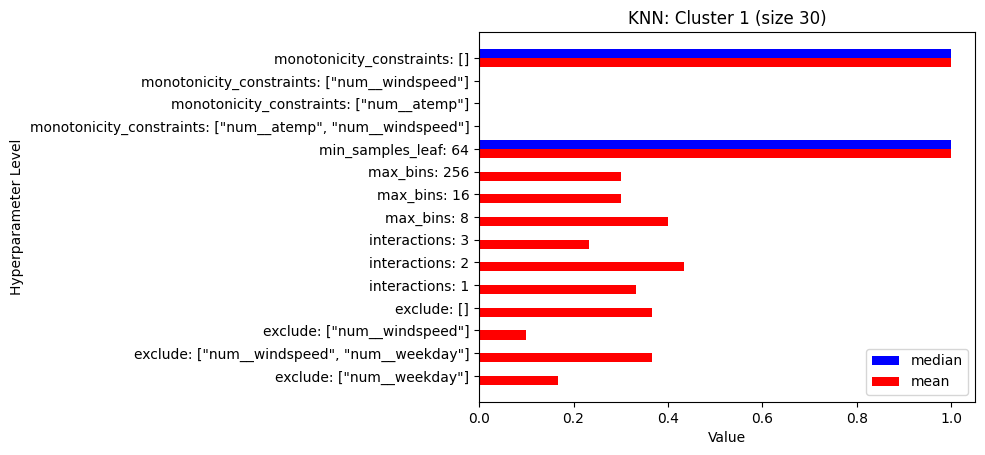

In [303]:
plot_cluster(data, labels, 1, hyperparameterLevelList, "KNN")

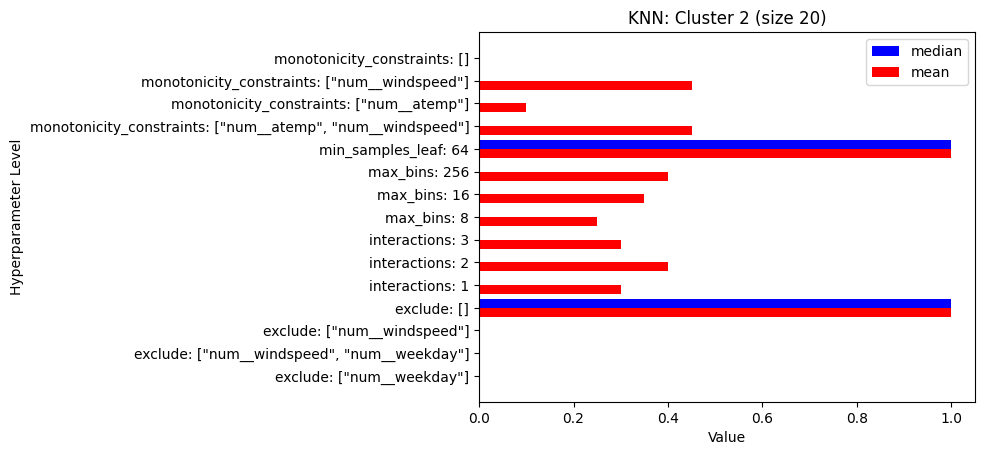

In [304]:
plot_cluster(data, labels, 2, hyperparameterLevelList, "KNN")

In [279]:
hyperparameterLevels = {
    "exclude": [
      "[\"num__weekday\"]",
      "[\"num__windspeed\", \"num__weekday\"]",
      "[\"num__windspeed\"]",
      "[]"
    ],
    "interactions": [
      "1",
      "2",
      "3"
    ],
    "max_bins": [
      "8",
      "16",
      "256"
    ],
    "min_samples_leaf": [
      "64"
    ],
    "monotonicity_constraints": [
      "[\"num__atemp\", \"num__windspeed\"]",
      "[\"num__atemp\"]",
      "[\"num__windspeed\"]",
      "[]"
    ]
}
hyperparameterLevelList = [f"{name}: {level}" for name,levels in hyperparameterLevels.items() for level in levels]

In [280]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Example data
data = encoding_evolution[:,0,:]

n_clusters = 3
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
labels = agg_clustering.fit_predict(data)

print("Cluster Sizes:")
for k in range(n_clusters):
    print(f"Cluster {k}: {data[labels==k,:].shape[0]}")

Cluster Sizes:
Cluster 0: 26
Cluster 1: 27
Cluster 2: 25


In [293]:
def plot_cluster(data: np.ndarray, labels: np.ndarray, cluster: int, hyperparameterLevelList, algo):
    median_values = np.median(data[labels == cluster, :], axis=0)
    mean_values = np.mean(data[labels == cluster, :], axis=0)


    bar_width = 0.4
    y_positions = np.arange(len(hyperparameterLevelList))

    plt.barh(y_positions + bar_width / 2, median_values, height=bar_width, label="median", color="blue")
    plt.barh(y_positions - bar_width / 2, mean_values, height=bar_width, label="mean", color="red")

    # Add labels, title, and legend
    plt.yticks(y_positions, hyperparameterLevelList)
    plt.xlabel("Value")
    plt.ylabel("Hyperparameter Level")
    plt.legend()
    plt.title(f"{algo}: Cluster {cluster} (size {data[labels==cluster,:].shape[0]})")

    plt.show()

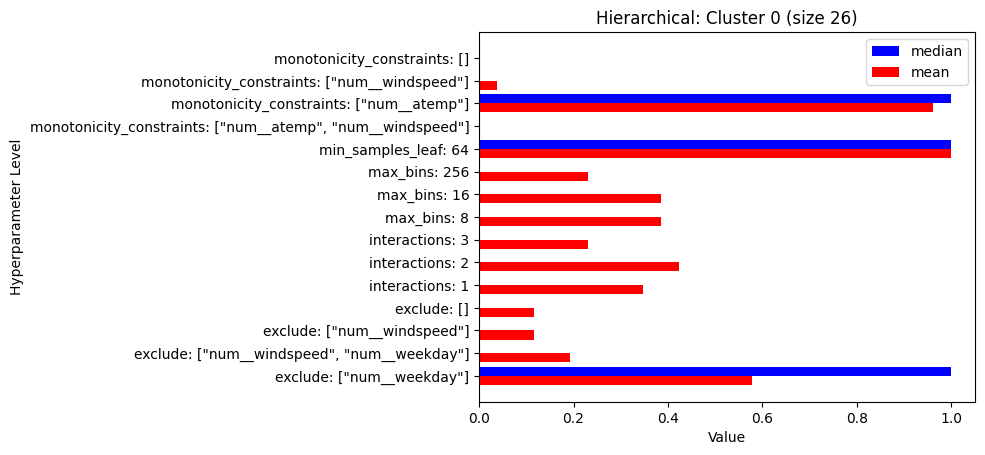

In [294]:
plot_cluster(data, labels, 0, hyperparameterLevelList, "Hierarchical")

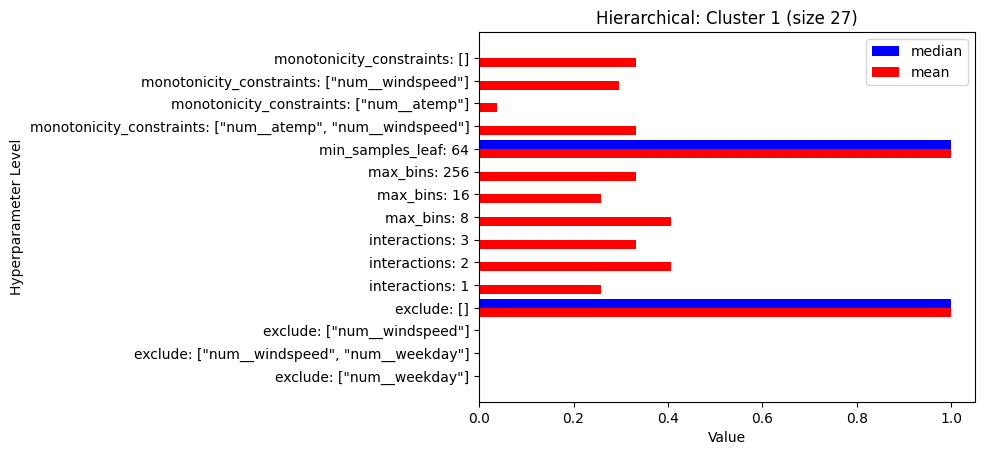

In [295]:
plot_cluster(data, labels, 1, hyperparameterLevelList, "Hierarchical")

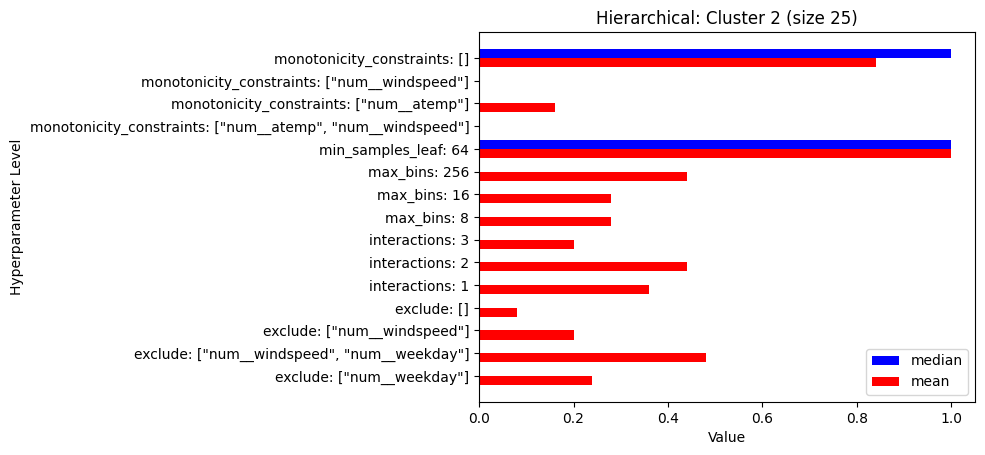

In [296]:
plot_cluster(data, labels, 2, hyperparameterLevelList, "Hierarchical")

In [285]:
sigma2_evolution = np.array([
    [response["userContext"]["sigma2"]
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in personalization_context.items()])

In [286]:
sigma2_evolution.shape

(78, 11, 15)

In [288]:
total_variances_by_user = np.power(np.prod(sigma2_evolution, axis=2), 1/sigma2_evolution.shape[2])[:,::-1]

In [693]:
total_variances_by_user.shape

(78, 11)

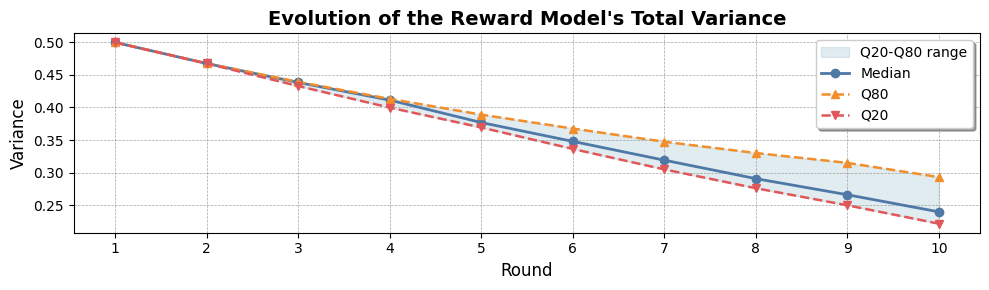

In [322]:
rewards_by_level = np.array([
    [int(request["reward"]) * np.array(response["encoding"]) 
     for request, response in zip(val["requestStack"], val["responseStack"][1:])] 
     for key, val in {**personalization_context1, **personalization_context2}.items()])
   

In [323]:
rewards_by_level.shape

(138, 10, 15)

In [327]:
np.unique(ratings_by_level[0,:,0])

array([-1,  0,  1])

In [325]:
np.count

AttributeError: module 'numpy' has no attribute 'count'

In [493]:
def entropy(arr: np.ndarray, axis: int) -> np.ndarray:
    # Count the number of 1s and non-zero entries along the specified axis
    n_p1 = (arr == 1).sum(axis=axis)
    n_total = (arr != 0).sum(axis=axis)
    
    # Calculate q1, setting to NaN when n_total is zero
    q1 = np.where(n_total != 0, n_p1 / n_total, np.nan)
    
    # Compute entropy with additional handling for q1 = 0 or q1 = 1
    entropy = np.where(
        (q1 == 0) | (q1 == 1) | np.isnan(q1), 
        0,  # Entropy is 0 when q1 is 0, 1, or undefined
        -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
    )
    
    return entropy


def mean_nonzero(arr: np.ndarray, axis: int) -> np.ndarray:
    # Sum all non-zero elements along the specified axis
    sum_nonzero = np.sum(arr * (arr != 0), axis=axis)
    
    # Count the number of non-zero elements along the specified axis
    count_nonzero = np.count_nonzero(arr, axis=axis)
    
    # Compute the mean, handling division by zero when no non-zero entries are present
    mean_nonzero = np.true_divide(sum_nonzero, count_nonzero, where=(count_nonzero != 0))
    
    return mean_nonzero

from typing import Callable, Optional

def apply_on_subset(arr: np.ndarray, predicate: Callable[[np.ndarray], np.ndarray], 
                    operation: Callable[[np.ndarray], np.ndarray], axis: int, 
                    fill_value: Optional[float] = np.nan) -> np.ndarray:
    """
    Apply an operation along an axis on a subset of entries in a NumPy array.
    
    Parameters:
    - arr: np.ndarray - Input array.
    - predicate: Callable[[np.ndarray], np.ndarray] - Function that takes `arr` and returns a boolean mask array.
    - operation: Callable[[np.ndarray], np.ndarray] - Operation to apply on the subset of entries.
    - axis: int - Axis along which to apply the operation.
    - fill_value: Optional[float] - Value to use where there are no entries satisfying the predicate. Default is NaN.
    
    Returns:
    - np.ndarray - Result after applying the operation on the subset along the specified axis.
    """
    # Create a mask using the predicate
    mask = predicate(arr)
    
    # Replace entries that don't satisfy the predicate with the fill_value
    subset = np.where(mask, arr, fill_value)
    print(subset)
    
    # Apply the operation along the specified axis, ignoring the fill_value
    result = operation(subset, axis=axis)
    
    return result

In [481]:
entropy_by_level = entropy(ratings_by_level, axis=1)
abs_mean_by_level = np.abs(np.mean(ratings_by_level, axis=1))
var_by_level = apply_on_subset(x!=)np.abs(np.mean(ratings_by_level, axis=1))

/tmp/ipykernel_224517/4137238102.py:7: RuntimeWarning: invalid value encountered in divide
  q1 = np.where(n_total != 0, n_p1 / n_total, np.nan)
/tmp/ipykernel_224517/4137238102.py:13: RuntimeWarning: divide by zero encountered in log2
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
/tmp/ipykernel_224517/4137238102.py:13: RuntimeWarning: invalid value encountered in multiply
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))


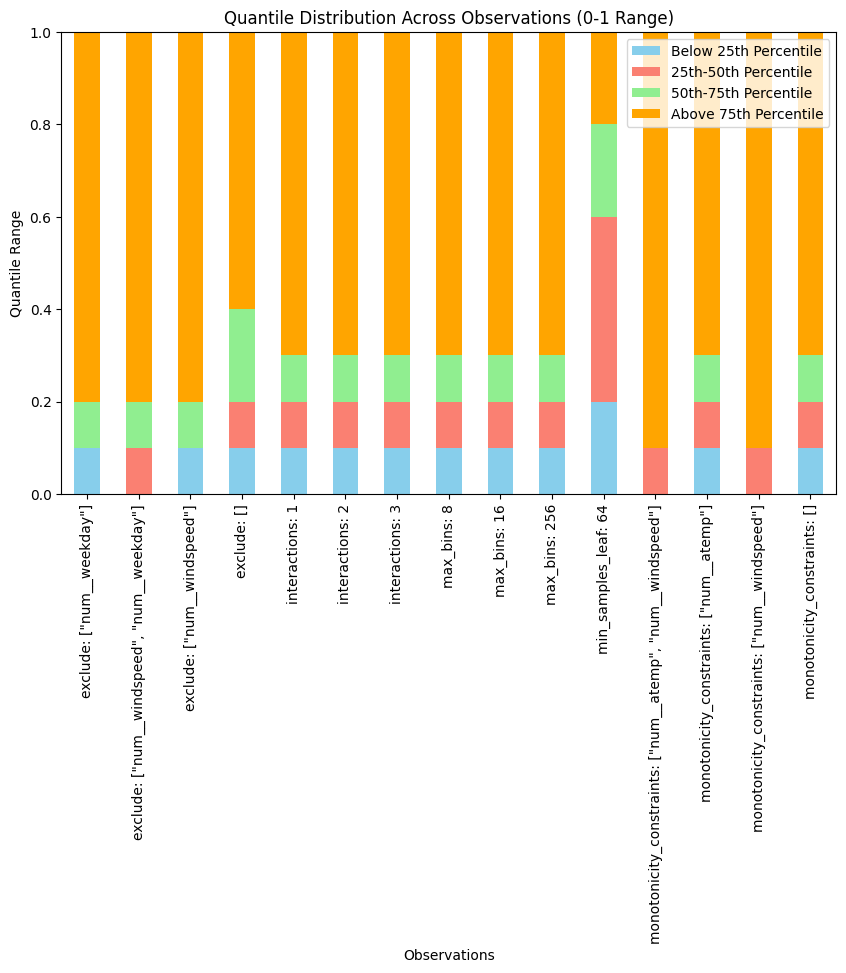

In [483]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample data: 4 observations with values between 0 and 1
np.random.seed(0)
data = {
    level: entropy_by_level[:,k] for k, level in enumerate(hyperparameterLevelList)
}
data = {
    level: abs_mean_by_level[:,k] for k, level in enumerate(hyperparameterLevelList)
}
data = {
    level: var_by_level[:,k] for k, level in enumerate(hyperparameterLevelList)
}
df = pd.DataFrame(data)

# Compute quantiles for each observation
quantiles = {}
for column in df.columns:
    quantiles[column] = {
        'Below 25th': np.percentile(df[column], 25),
        '25th-50th': np.percentile(df[column], 50) - np.percentile(df[column], 25),
        '50th-75th': np.percentile(df[column], 75) - np.percentile(df[column], 50),
        'Above 75th': 1 - np.percentile(df[column], 75)  # assuming range is [0, 1]
    }

# Convert to DataFrame for plotting
quantiles_df = pd.DataFrame(quantiles).T
quantiles_df = quantiles_df[['Below 25th', '25th-50th', '50th-75th', 'Above 75th']]

# Plot stacked bar chart
quantiles_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon', 'lightgreen', 'orange'])

# Add labels and title
plt.title('Quantile Distribution Across Observations (0-1 Range)')
plt.xlabel('Observations')
plt.ylabel('Quantile Range')
plt.legend(['Below 25th Percentile', '25th-50th Percentile', '50th-75th Percentile', 'Above 75th Percentile'])
plt.ylim(0, 1)  # Ensure y-axis covers the full 0-1 range
plt.show()


/tmp/ipykernel_224517/4137238102.py:7: RuntimeWarning: invalid value encountered in divide
  q1 = np.where(n_total != 0, n_p1 / n_total, np.nan)
/tmp/ipykernel_224517/4137238102.py:13: RuntimeWarning: divide by zero encountered in log2
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
/tmp/ipykernel_224517/4137238102.py:13: RuntimeWarning: invalid value encountered in multiply
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))


(array([[ 96.,   0.,   0.,   0.,   0.,   0.,   1.,   3.,   8.,  30.],
        [103.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   6.,  27.],
        [ 96.,   0.,   0.,   0.,   0.,   1.,   0.,   3.,   4.,  34.],
        [ 62.,   0.,   0.,   0.,   0.,   4.,   6.,   5.,  13.,  48.],
        [ 67.,   0.,   0.,   0.,   0.,   0.,   4.,   6.,  10.,  51.],
        [ 77.,   0.,   0.,   0.,   0.,   3.,   5.,   5.,  11.,  37.],
        [ 82.,   0.,   0.,   0.,   0.,   2.,   2.,   4.,   7.,  41.],
        [ 64.,   0.,   0.,   0.,   0.,   2.,   2.,   7.,  11.,  52.],
        [ 72.,   0.,   0.,   0.,   0.,   1.,   3.,   9.,  16.,  37.],
        [ 78.,   0.,   0.,   0.,   0.,   1.,   6.,   2.,  10.,  41.],
        [ 21.,   0.,   0.,   0.,  19.,   0.,   0.,  30.,  32.,  36.],
        [126.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  12.],
        [ 62.,   0.,   0.,   0.,   0.,   3.,   3.,  10.,  13.,  47.],
        [122.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,  14.],
        [ 60.,   0.,

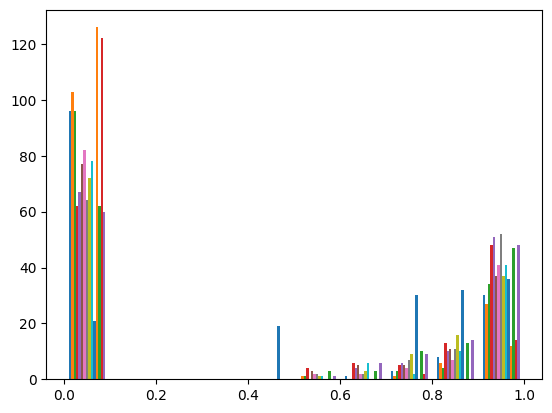

In [477]:
plt.hist(entropy(ratings_by_level, axis=1))

In [490]:
(ratings_by_level != 0).sum(axis=1)

array([[4, 0, 1, ..., 4, 1, 3],
       [1, 4, 2, ..., 4, 3, 3],
       [1, 1, 0, ..., 3, 1, 3],
       ...,
       [0, 0, 2, ..., 4, 0, 4],
       [3, 2, 4, ..., 6, 0, 3],
       [5, 2, 1, ..., 4, 1, 5]])

In [495]:
predicate = lambda x: x != 0
operation = np.mean

result = apply_on_subset(ratings_by_level, predicate, operation, axis=1)

[[[nan nan nan ... nan nan  1.]
  [-1. nan nan ... -1. nan nan]
  [ 1. nan nan ... nan nan  1.]
  ...
  [nan nan nan ... nan nan nan]
  [ 1. nan nan ...  1. nan nan]
  [ 1. nan nan ...  1. nan nan]]

 [[-1. nan nan ... nan nan -1.]
  [nan nan  1. ... nan nan  1.]
  [nan -1. nan ... nan nan -1.]
  ...
  [nan nan nan ... nan  1. nan]
  [nan  1. nan ...  1. nan nan]
  [nan nan nan ... nan  1. nan]]

 [[nan -1. nan ... nan nan -1.]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan -1.]
  ...
  [nan nan nan ... -1. nan nan]
  [nan nan nan ... -1. nan nan]
  [-1. nan nan ... nan nan -1.]]

 ...

 [[nan nan nan ...  1. nan nan]
  [nan nan  1. ... nan nan  1.]
  [nan nan nan ... nan nan  1.]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan  1.]]

 [[nan nan -1. ... -1. nan nan]
  [nan  1. nan ...  1. nan nan]
  [nan -1. nan ... nan nan -1.]
  ...
  [ 1. nan nan ...  1. nan nan]
  [-1. nan nan ... nan nan -1.]
  [ 1. nan nan ...  1. nan n

In [548]:
x

'2'

In [596]:
n_users, n_rounds, n_hparams = rewards_by_level.shape
nonzero_ratings = {
    hyperparameterLevelList[i]: [
        l for j in range(n_users) if len(l:=[reward for reward in rewards_by_level[j,:,i] if reward != 0]) > 1] 
    for i in range(n_hparams)
}

In [599]:
def plot_stacked_quantiles(data):
    # Compute quantiles for each observation
    df = pd.DataFrame(data)
    quantiles = {}
    for column in df.columns:
        quantiles[column] = {
            'Below 25th': np.percentile(df[column], 25),
            '25th-50th': np.percentile(df[column], 50) - np.percentile(df[column], 25),
            '50th-75th': np.percentile(df[column], 75) - np.percentile(df[column], 50),
            'Above 75th': 1 - np.percentile(df[column], 75)  # assuming range is [0, 1]
        }

    # Convert to DataFrame for plotting
    quantiles_df = pd.DataFrame(quantiles).T
    print(quantiles_df)
    quantiles_df = quantiles_df[['Below 25th', '25th-50th', '50th-75th', 'Above 75th']]

    # Plot stacked bar chart
    quantiles_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon', 'lightgreen', 'orange'])

    # Add labels and title
    plt.title('Quantile Distribution Across Observations (0-1 Range)')
    plt.xlabel('Observations')
    plt.ylabel('Quantile Range')
    plt.legend(['Below 25th Percentile', '25th-50th Percentile', '50th-75th Percentile', 'Above 75th Percentile'])
    plt.ylim(0, 1)  # Ensure y-axis covers the full 0-1 range
    plt.show()

In [715]:
abbreviated_levels = {
    'exclude: ["num__weekday"]': "A-1",
    'exclude: ["num__windspeed", "num__weekday"]': "A-2",
    'exclude: ["num__windspeed"]': "A-3",
    'exclude: []': "A-4",
    'interactions: 1': "B-1",
    'interactions: 2': "B-2",
    'interactions: 3': "B-3",
    'max_bins: 8': "C-1",
    'max_bins: 16': "C-2",
    'max_bins: 256': "C-3",
    'min_samples_leaf: 64': "D-1",
    'monotonicity_constraints: ["num__atemp", "num__windspeed"]': "D-1",
    'monotonicity_constraints: ["num__atemp"]': "D-2",
    'monotonicity_constraints: ["num__windspeed"]': "D-3",
    'monotonicity_constraints: []': "D-4",
}

In [716]:
entropy_data.keys()

dict_keys(['exclude: ["num__weekday"]', 'exclude: ["num__windspeed", "num__weekday"]', 'exclude: ["num__windspeed"]', 'exclude: []', 'interactions: 1', 'interactions: 2', 'interactions: 3', 'max_bins: 8', 'max_bins: 16', 'max_bins: 256', 'monotonicity_constraints: ["num__atemp", "num__windspeed"]', 'monotonicity_constraints: ["num__atemp"]', 'monotonicity_constraints: ["num__windspeed"]', 'monotonicity_constraints: []'])

/tmp/ipykernel_224517/1329529943.py:13: RuntimeWarning: divide by zero encountered in log2
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
/tmp/ipykernel_224517/1329529943.py:13: RuntimeWarning: invalid value encountered in multiply
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))
/tmp/ipykernel_224517/1329529943.py:13: RuntimeWarning: invalid value encountered in scalar multiply
  -(q1 * np.log2(q1) + (1 - q1) * np.log2(1 - q1))


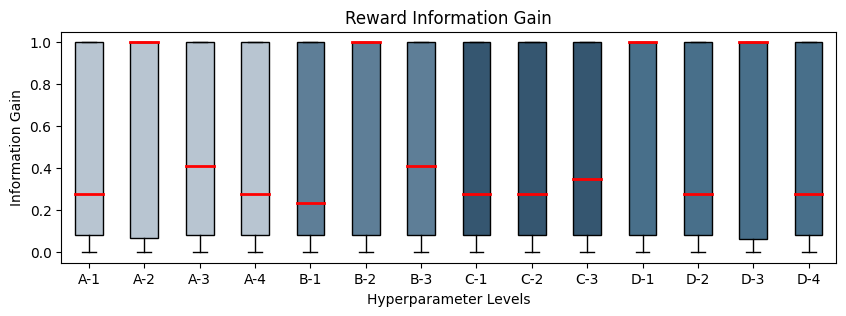

In [718]:
entropy_data = {
    key: 1- np.array([entropy(np.array(v), axis=0) for v in val]) for key, val in nonzero_ratings.items() if key != 'min_samples_leaf: 64'
}

data = list(entropy_data.values())
labels = [abbreviated_levels[level] for level in entropy_data.keys()]

fig, ax = plt.subplots(figsize=(10,3))

bplot = ax.boxplot(data, labels=labels, patch_artist=True, medianprops={"color": "red", "linewidth": 2})

vcolors = (
    4 * ["#B8C5D1"] +   # Light Slate Blue (slightly brighter for contrast)
    3 * ["#5E7E97"] +   # Medium Dusty Blue (a bit richer in tone)
    3 * ["#355670"] +   # Deep Slate Blue (providing more contrast)
    #["#1F3A4D"] +       # Charcoal Blue (dark and grounding)
    4 * ["#486F8A"]     # Steel Blue (a bit more saturated for vibrancy)
)

for patch, color in zip(bplot['boxes'], vcolors):
    patch.set_facecolor(color)

ax.set_xlabel("Hyperparameter Levels")
ax.set_ylabel("Information Gain")
ax.set_title("Reward Information Gain")
plt.savefig("information_gain.svg")

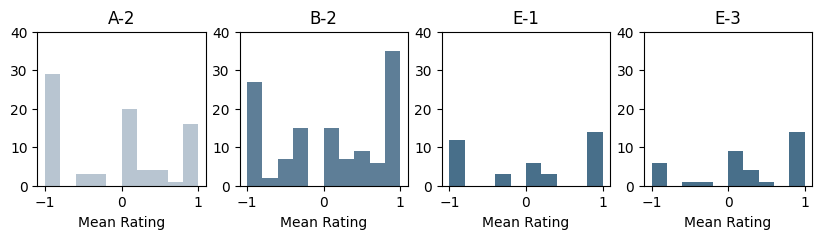

In [710]:
mean_data = {
    key: np.array([np.mean(np.array(v), axis=0) for v in val]) for key, val in nonzero_ratings.items()
}

plt.figure(figsize=(10,2))

plt.subplot(1,4,1)
plt.title("A-2")
plt.hist(mean_data['exclude: ["num__windspeed", "num__weekday"]'], color="#B8C5D1")
plt.ylim(0,40)
plt.xlabel("Mean Rating")

plt.subplot(1,4,2)
plt.title("B-2")
plt.hist(mean_data['interactions: 2'], color="#5E7E97")
plt.ylim(0,40)
plt.xlabel("Mean Rating")

plt.subplot(1,4,3)
plt.title("E-1")
plt.hist(mean_data['monotonicity_constraints: ["num__atemp", "num__windspeed"]'], color="#486F8A")
plt.ylim(0,40)
plt.xlabel("Mean Rating")

plt.subplot(1,4,4)
plt.title("E-3")
plt.hist(mean_data['monotonicity_constraints: ["num__windspeed"]'], color="#486F8A")
plt.ylim(0,40)
plt.xlabel("Mean Rating")

plt.savefig("high_information_gain_hyperaparameter_levels.svg")

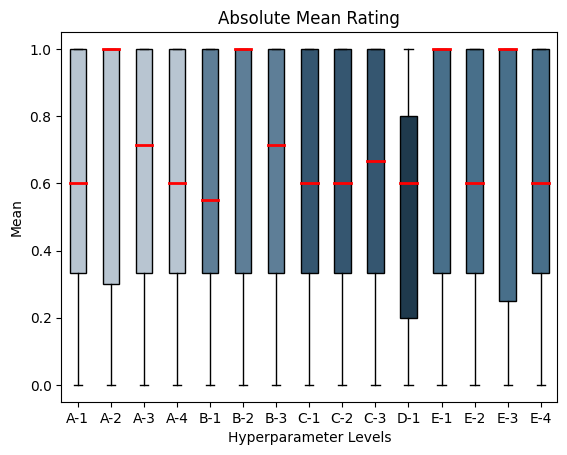

In [666]:
mean_data = {
    key: np.array([np.abs(np.mean(np.array(v), axis=0)) for v in val]) for key, val in nonzero_ratings.items()
}

data = list(mean_data.values())
labels = [abbreviated_levels[level] for level in mean_data.keys()]

fig, ax = plt.subplots()

bplot = ax.boxplot(data, labels=labels, patch_artist=True, medianprops={"color": "red", "linewidth": 2})

vcolors = (
    4 * ["#B8C5D1"] +   # Light Slate Blue (slightly brighter for contrast)
    3 * ["#5E7E97"] +   # Medium Dusty Blue (a bit richer in tone)
    3 * ["#355670"] +   # Deep Slate Blue (providing more contrast)
    ["#1F3A4D"] +       # Charcoal Blue (dark and grounding)
    4 * ["#486F8A"]     # Steel Blue (a bit more saturated for vibrancy)
)

for patch, color in zip(bplot['boxes'], vcolors):
    patch.set_facecolor(color)

ax.set_xlabel("Hyperparameter Levels")
ax.set_ylabel("Mean")
ax.set_title("Absolute Mean Rating")
plt.show()

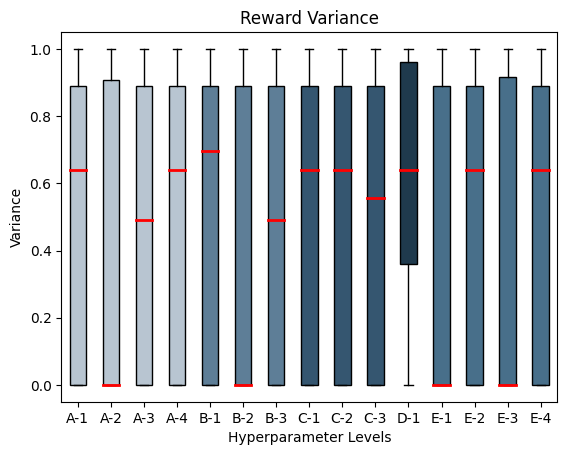

In [663]:
var_data = {
    key: np.array([np.var(np.array(v), axis=0) for v in val]) for key, val in nonzero_ratings.items()
}

data = list(var_data.values())
labels = [abbreviated_levels[level] for level in mean_data.keys()]

fig, ax = plt.subplots()

bplot = ax.boxplot(data, labels=labels, patch_artist=True, medianprops={"color": "red", "linewidth": 2})

vcolors = (
    4 * ["#B8C5D1"] +   # Light Slate Blue (slightly brighter for contrast)
    3 * ["#5E7E97"] +   # Medium Dusty Blue (a bit richer in tone)
    3 * ["#355670"] +   # Deep Slate Blue (providing more contrast)
    ["#1F3A4D"] +       # Charcoal Blue (dark and grounding)
    4 * ["#486F8A"]     # Steel Blue (a bit more saturated for vibrancy)
)

for patch, color in zip(bplot['boxes'], vcolors):
    patch.set_facecolor(color)

ax.set_xlabel("Hyperparameter Levels")
ax.set_ylabel("Variance")
ax.set_title("Reward Variance")
plt.show()

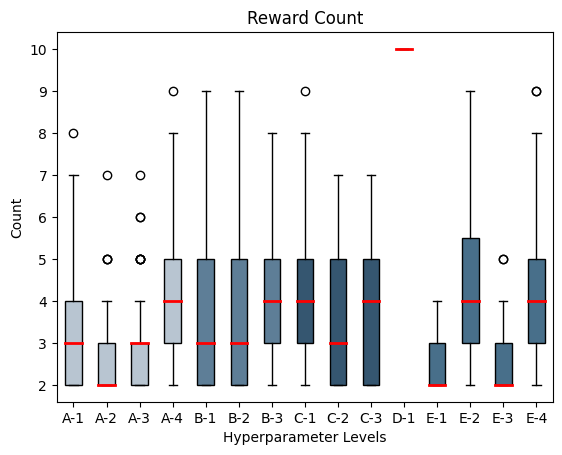

In [665]:
count_data = {
    key: np.array([len(v) for v in val]) for key, val in nonzero_ratings.items()
}

data = list(count_data.values())
labels = [abbreviated_levels[level] for level in mean_data.keys()]

fig, ax = plt.subplots()

bplot = ax.boxplot(data, labels=labels, patch_artist=True, medianprops={"color": "red", "linewidth": 2})

vcolors = (
    4 * ["#B8C5D1"] +   # Light Slate Blue (slightly brighter for contrast)
    3 * ["#5E7E97"] +   # Medium Dusty Blue (a bit richer in tone)
    3 * ["#355670"] +   # Deep Slate Blue (providing more contrast)
    ["#1F3A4D"] +       # Charcoal Blue (dark and grounding)
    4 * ["#486F8A"]     # Steel Blue (a bit more saturated for vibrancy)
)

for patch, color in zip(bplot['boxes'], vcolors):
    patch.set_facecolor(color)

ax.set_xlabel("Hyperparameter Levels")
ax.set_ylabel("Count")
ax.set_title("Reward Count")
plt.show()

In [711]:
sum([])

0